# Conformer

## Installations and imports

In [ ]:
!apt-get install -y build-essential libboost-all-dev cmake
!pip install --upgrade --force-reinstall https://github.com/kpu/kenlm/archive/master.zip
!pip install pyctcdecode


In [ ]:
import kenlm
print(hasattr(kenlm, "Model"))  #i had some issues with importing for the first time, so i needed to check this


True


In [ ]:
!pip install num2words

In [ ]:
import pandas as pd
import os
from num2words import num2words

In [ ]:
import torch
import torchaudio
import torchaudio.transforms as T

In [ ]:
import torchaudio.transforms as T
import random

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from torch.nn.utils.rnn import pad_sequence

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
from torch.utils.data import Sampler

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
from jiwer import cer
from tqdm import tqdm

In [ ]:
!pip install python-Levenshtein


## Data Loading

In [ ]:
CSV_PATH_TRAIN = "/kaggle/input/asr-data/train/train.csv"
AUDIO_ROOT_TRAIN = "/kaggle/input/asr-data/train/"


In [ ]:
VAL_CSV_PATH = "/kaggle/input/asr-data/val/dev.csv"
VAL_AUDIO_ROOT = "/kaggle/input/asr-data/val"

In [ ]:
def normalize_number_to_text(number: int) -> str:
    text = num2words(number, lang="ru")
    return text.replace(",", "")



In [ ]:
def load_data(csv_path: str, audio_root: str):
    df = pd.read_csv(csv_path)
    samples = []
    for _, row in df.iterrows():
        full_path = os.path.join(audio_root, row["filename"])
        transcription_text = normalize_number_to_text(int(row["transcription"]))
        sample = {
            "wav_path": full_path,
            "text": transcription_text,
            "spk_id": row["spk_id"],
        }
        samples.append(sample)
    return samples


## Data Prep

In [ ]:
samples_train = load_data(
    csv_path=CSV_PATH_TRAIN,
    audio_root=AUDIO_ROOT_TRAIN
)


In [ ]:
samples_val = load_data(
    csv_path=VAL_CSV_PATH,
    audio_root=VAL_AUDIO_ROOT
)

In [ ]:
def build_vocab(samples):
    charset = set()
    for sample in samples:
        charset.update(sample["text"])
    charset = sorted(list(charset))
    char2idx = {c: i + 1 for i, c in enumerate(charset)}  # +1 'cause of 'PAD
    char2idx["<PAD>"] = 0
    idx2char = {i: c for c, i in char2idx.items()}
    return char2idx, idx2char


In [ ]:
char2idx, idx2char = build_vocab(samples_train)
print(char2idx)


{' ': 1, 'а': 2, 'в': 3, 'д': 4, 'е': 5, 'и': 6, 'к': 7, 'м': 8, 'н': 9, 'о': 10, 'п': 11, 'р': 12, 'с': 13, 'т': 14, 'ц': 15, 'ч': 16, 'ш': 17, 'ы': 18, 'ь': 19, 'я': 20, '<PAD>': 0}


In [ ]:
# quick check

for sample in samples_train[:5]:
    waveform, sr = torchaudio.load(sample['wav_path'])
    print(f"{sample['wav_path']}: shape={waveform.shape}, sr={sr}")

/kaggle/input/asr-data/train/train/0007c21c23.wav: shape=torch.Size([1, 73059]), sr=24000
/kaggle/input/asr-data/train/train/000bee1b1d.wav: shape=torch.Size([1, 77220]), sr=24000
/kaggle/input/asr-data/train/train/001a718902.wav: shape=torch.Size([1, 77469]), sr=22050
/kaggle/input/asr-data/train/train/001e8e5565.wav: shape=torch.Size([1, 73629]), sr=22050
/kaggle/input/asr-data/train/train/001ee5be6b.wav: shape=torch.Size([1, 74453]), sr=24000


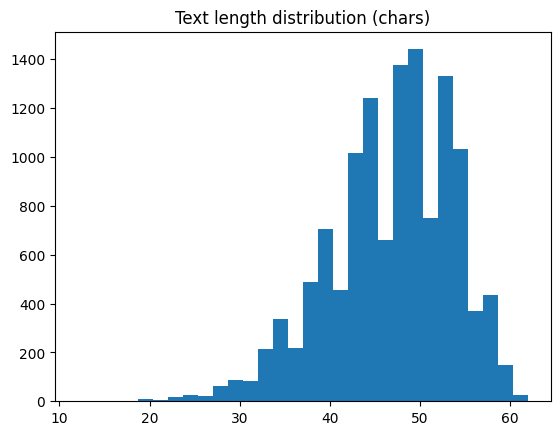

In [ ]:
import matplotlib.pyplot as plt

text_lengths = [len(sample['text']) for sample in samples_train]
plt.hist(text_lengths, bins=30)
plt.title("Text length distribution (chars)")
plt.show()


In [ ]:
for sample in samples_train:
    if not os.path.exists(sample["wav_path"]):
        print("Missing file:", sample["wav_path"])
    if not sample["text"]:
        print("Empty transcription:", sample)


seems okay, let's jump to resampling

In [ ]:
def load_data(csv_path: str, audio_root: str, target_sr: int = 16000):
    df = pd.read_csv(csv_path)
    samples = []

    for _, row in df.iterrows():
        full_path = os.path.join(audio_root, row["filename"])
        waveform, sr = torchaudio.load(full_path)

        if sr != target_sr:
            resampler = torchaudio.transforms.Resample(sr, target_sr)
            waveform = resampler(waveform)

        text = normalize_number_to_text(int(row["transcription"]))
        sample = {
            "wav_path": full_path,
            "waveform": waveform,
            "text": text,
            "spk_id": row["spk_id"],
            "input_len": waveform.shape[-1] // 160,  # logmel time steps
        }
        samples.append(sample)

    return samples


In [ ]:
samples_train = load_data(
    csv_path=CSV_PATH_TRAIN,
    audio_root=AUDIO_ROOT_TRAIN,
    target_sr=16000
)

In [ ]:
samples_train[0]

{'wav_path': '/kaggle/input/asr-data/train/train/0007c21c23.wav',
 'waveform': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'text': 'сто тридцать девять тысяч четыреста семьдесят три',
 'spk_id': 'spk_E',
 'input_len': 304}

In [ ]:
samples_val = load_data(
    csv_path=VAL_CSV_PATH,
    audio_root=VAL_AUDIO_ROOT,
    target_sr=16000
)

In [ ]:
samples_val[0]

{'wav_path': '/kaggle/input/asr-data/val/dev/0025d6d9a9.wav',
 'waveform': tensor([[-0.0002, -0.0005, -0.0013,  ..., -0.0017, -0.0010, -0.0003]]),
 'text': 'восемьсот сорок девять тысяч девятьсот пять',
 'spk_id': 'spk_J',
 'input_len': 240}

In [ ]:
class SpeechDataset(torch.utils.data.Dataset):
    def __init__(self, samples, char2idx, target_sample_rate=16000, train=False):
        self.samples = samples
        self.char2idx = char2idx
        self.target_sr = target_sample_rate
        self.train = train

        self.melspec = T.MelSpectrogram(
            sample_rate=target_sample_rate,
            n_fft=400,
            win_length=400,
            hop_length=160,
            n_mels=80
        )

        # augmentations
        self.vol = T.Vol(gain=(0.8, 1.2), gain_type="multiplicative")
        self.freq_mask = T.FrequencyMasking(freq_mask_param=1)
        self.time_mask = T.TimeMasking(time_mask_param=30)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        waveform = sample["waveform"]

        if self.train:
            if random.random() < 0.5:
                waveform = self.vol(waveform)
            if random.random() < 0.5:
                waveform = self.freq_mask(waveform)
            if random.random() < 0.5:
                waveform = self.time_mask(waveform)

        melspec = self.melspec(waveform).squeeze(0)
        log_melspec = torch.log(melspec + 1e-6)

        text = sample["text"]
        tokens = [self.char2idx[c] for c in text]
        output = {
            "logmel": log_melspec,
            "tokens": torch.tensor(tokens, dtype=torch.long),
            "input_len": log_melspec.shape[-1],
            "target_len": len(tokens),
            "spk_id": sample["spk_id"]
        }

        if not self.train:
            output["text"] = text

        return output

In [ ]:
for i, sample in enumerate(samples_train):
    if sample["waveform"].ndim != 2 or sample["waveform"].shape[0] != 1:
        print(f"Sample {i} has invalid shape: {sample['waveform'].shape}")


seems okay again, let's create datasets

In [ ]:
train_dataset = SpeechDataset(samples_train, char2idx, train=True)

In [ ]:
example = train_dataset[0]
example

{'logmel': tensor([[-12.6838, -13.2824,  -9.6527,  ..., -13.8155, -13.8155, -13.8155],
         [-11.6632, -12.5487,  -8.3775,  ..., -13.8155, -13.8155, -13.8155],
         [-13.3546, -13.0742,  -9.3259,  ..., -13.8155, -13.8155, -13.8155],
         ...,
         [-13.8151, -13.8150, -13.8008,  ..., -13.8155, -13.8155, -13.8155],
         [-13.8131, -13.8148, -13.8006,  ..., -13.8155, -13.8155, -13.8155],
         [-13.8142, -13.8149, -13.8082,  ..., -13.8155, -13.8155, -13.8155]]),
 'tokens': tensor([13, 14, 10,  1, 14, 12,  6,  4, 15,  2, 14, 19,  1,  4,  5,  3, 20, 14,
         19,  1, 14, 18, 13, 20, 16,  1, 16,  5, 14, 18, 12,  5, 13, 14,  2,  1,
         13,  5,  8, 19,  4,  5, 13, 20, 14,  1, 14, 12,  6]),
 'input_len': 305,
 'target_len': 49,
 'spk_id': 'spk_E'}

hmm, but first - quick check for the correct augmentation

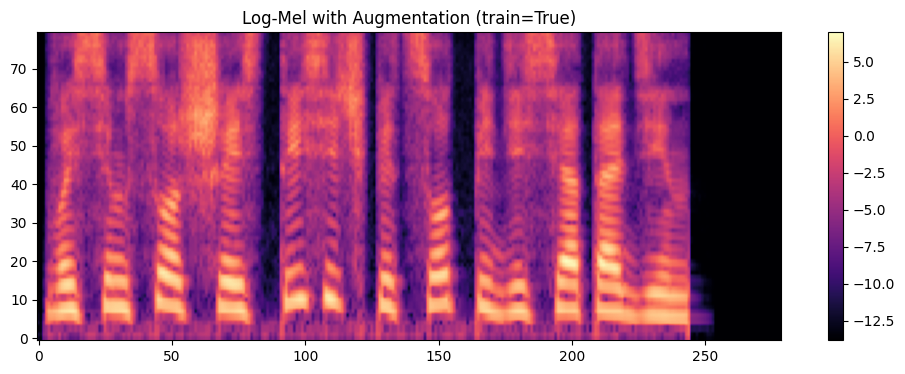

In [ ]:
sample = train_dataset[5]
logmel = sample["logmel"]

plt.figure(figsize=(12, 4))
plt.imshow(logmel.numpy(), origin="lower", aspect="auto", cmap="magma")
plt.title("Log-Mel with Augmentation (train=True)")
plt.colorbar()
plt.show()

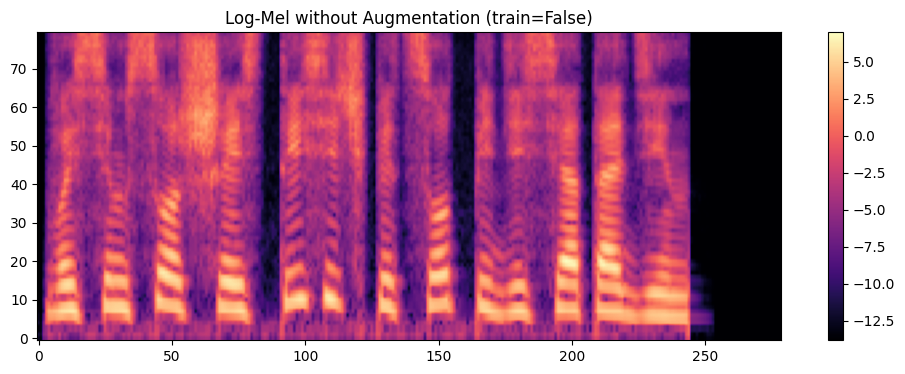

In [ ]:
dataset_clean = SpeechDataset(samples_train, char2idx, train=False)
logmel_clean = dataset_clean[5]["logmel"]

plt.figure(figsize=(12, 4))
plt.imshow(logmel_clean.numpy(), origin="lower", aspect="auto", cmap="magma")
plt.title("Log-Mel without Augmentation (train=False)")
plt.colorbar()
plt.show()

In [ ]:
print(example["logmel"].shape)

torch.Size([80, 305])


In [ ]:
print(example["tokens"])

tensor([13, 14, 10,  1, 14, 12,  6,  4, 15,  2, 14, 19,  1,  4,  5,  3, 20, 14,
        19,  1, 14, 18, 13, 20, 16,  1, 16,  5, 14, 18, 12,  5, 13, 14,  2,  1,
        13,  5,  8, 19,  4,  5, 13, 20, 14,  1, 14, 12,  6])


In [ ]:
print(example["spk_id"])

spk_E


In [ ]:
def collate_fn(batch):
    logmels = [item["logmel"] for item in batch]
    tokens = [item["tokens"] for item in batch]

    logmel_lengths = torch.tensor([item["input_len"] for item in batch], dtype=torch.long)
    token_lengths = torch.tensor([item["target_len"] for item in batch], dtype=torch.long)


    logmels_padded = pad_sequence([x.transpose(0, 1) for x in logmels], batch_first=True).transpose(1, 2)
    tokens_padded = pad_sequence(tokens, batch_first=True, padding_value=0).long()
    texts = [item["text"] for item in batch if "text" in item]


    return {
        "logmel": logmels_padded,     # [B, n_mels, time]
        "logmel_len": logmel_lengths, # [B]
        "tokens": tokens_padded,      # [B, T]
        "token_len": token_lengths,
        "text": texts# [B]
    }


In [ ]:
class BucketBatchSampler(Sampler):
    def __init__(self, data, batch_size=32, boundaries=None, shuffle=True):
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.boundaries = boundaries or [100, 150, 200, 300, 500]


        self.buckets = {b: [] for b in range(len(self.boundaries) + 1)}
        for idx, sample in enumerate(data):
            length = sample["input_len"]
            bucket_id = self._get_bucket(length)
            self.buckets[bucket_id].append(idx)


        self.batch_indices = []
        for bucket in self.buckets.values():
            if self.shuffle:
                random.shuffle(bucket)
            for i in range(0, len(bucket), self.batch_size):
                self.batch_indices.append(bucket[i:i+self.batch_size])

        if self.shuffle:
            random.shuffle(self.batch_indices)

    def _get_bucket(self, length):
        for i, b in enumerate(self.boundaries):
            if length <= b:
                return i
        return len(self.boundaries)

    def __iter__(self):
        return iter(self.batch_indices)

    def __len__(self):
        return len(self.batch_indices)


In [ ]:
bucket_sampler = BucketBatchSampler(samples_train, batch_size=32)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_sampler=bucket_sampler,
    collate_fn=collate_fn
)

In [ ]:
val_dataset = SpeechDataset(samples_val, char2idx, train=False)

In [ ]:
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [ ]:
batch = next(iter(train_loader))


is batch created in a correct way? let's check!

In [ ]:
print("Logmel shape:", batch["logmel"].shape)       # [B, freq, time]
print("Tokens shape:", batch["tokens"].shape)       # [B, T]
print("Logmel lens:", batch["logmel_len"])          # real audio length
print("Token lens:", batch["token_len"])            # real token length


Logmel shape: torch.Size([32, 80, 462])
Tokens shape: torch.Size([32, 59])
Logmel lens: tensor([346, 315, 307, 311, 326, 337, 340, 370, 305, 371, 352, 376, 349, 374,
        306, 329, 332, 320, 306, 317, 324, 321, 303, 323, 338, 315, 366, 319,
        329, 344, 362, 462])
Token lens: tensor([57, 51, 51, 53, 41, 51, 53, 48, 48, 59, 57, 54, 55, 47, 47, 50, 53, 51,
        53, 52, 53, 52, 47, 55, 53, 52, 43, 49, 51, 40, 39, 56])


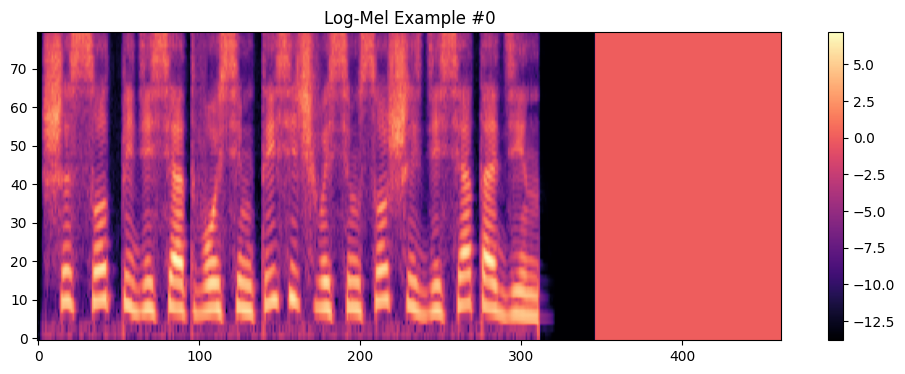

In [ ]:
i = 0
logmel = batch["logmel"][i].numpy()

plt.figure(figsize=(12, 4))
plt.imshow(logmel, origin="lower", aspect="auto", cmap="magma")
plt.title(f"Log-Mel Example #{i}")
plt.colorbar()
plt.show()

кажется, все в порядке! идем дальше

## Building Conformer

In [ ]:
print(len(char2idx))

21


In [ ]:
class ConvSubsampling(nn.Module):
    def __init__(self, in_channels, out_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        self.linear = nn.Linear(32 * (in_channels // 4), out_dim)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        B, D, C, T = x.shape
        x = x.permute(0, 3, 2, 1).reshape(B, T, C * D)
        x = self.linear(x)
        return x


class FeedForwardModule(nn.Module):
    def __init__(self, dim, expansion_factor=2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim * expansion_factor),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * expansion_factor, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class ConvModule(nn.Module):
    def __init__(self, dim, kernel_size=15):
        super().__init__()
        self.pointwise1 = nn.Conv1d(dim, 2 * dim, kernel_size=1)
        self.glu = nn.GLU(dim=1)
        self.depthwise = nn.Conv1d(dim, dim, kernel_size, padding=kernel_size // 2, groups=dim)
        self.batchnorm = nn.BatchNorm1d(dim)
        self.pointwise2 = nn.Conv1d(dim, dim, kernel_size=1)
        self.activation = nn.SiLU()

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.pointwise1(x)
        x = self.glu(x)
        x = self.depthwise(x)
        x = self.batchnorm(x)
        x = self.activation(x)
        x = self.pointwise2(x)
        return x.transpose(1, 2)


class ConformerBlock(nn.Module):
    def __init__(self, dim, n_heads=4, conv_kernel=15, dropout=0.1):
        super().__init__()
        self.ff1 = FeedForwardModule(dim)
        self.self_attn = nn.Sequential(
            nn.LayerNorm(dim),
            nn.MultiheadAttention(embed_dim=dim, num_heads=n_heads, dropout=dropout, batch_first=True)
        )
        self.conv = ConvModule(dim, kernel_size=conv_kernel)
        self.ff2 = FeedForwardModule(dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        x = x + 0.5 * self.ff1(x)
        x_attn, _ = self.self_attn[1](self.self_attn[0](x), self.self_attn[0](x), self.self_attn[0](x))
        x = x + x_attn
        x = x + self.conv(x)
        x = x + 0.5 * self.ff2(x)
        return self.norm(x)


class CompactConformerASR(nn.Module):
    def __init__(self, in_channels=80, num_classes=21, dim=224, num_layers=6, n_heads=8):
        super().__init__()
        self.subsample = ConvSubsampling(in_channels, dim)
        self.encoder = nn.Sequential(*[
            ConformerBlock(dim, n_heads=n_heads)
            for _ in range(num_layers)
        ])
        self.output = nn.Linear(dim, num_classes)

    def forward(self, x, input_lengths=None):
        x = self.subsample(x)
        x = self.encoder(x)
        x = self.output(x)
        return F.log_softmax(x, dim=-1)


In [ ]:
model = CompactConformerASR(
    in_channels=80,
    num_classes=21,
    dim=224,
    num_layers=6,
    n_heads=8
)


print(sum(p.numel() for p in model.parameters()))


4726133


In [ ]:
criterion = nn.CTCLoss(blank=0, zero_infinity=True)  # <PAD> = 0
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=3e-4)

In [ ]:
#check forwardpass

model.train()

batch = next(iter(train_loader))
logmel = batch["logmel"]
logmel_len = batch["logmel_len"]
tokens = batch["tokens"]
token_len = batch["token_len"]

log_probs = model(logmel)

input_len = logmel_len // 4

log_probs = log_probs.transpose(0, 1)

loss = criterion(log_probs, tokens, input_len, token_len)

print("Loss:", loss.item())

Loss: 3.879159450531006


In [ ]:
def train_loop(model, train_loader, val_loader, criterion, optimizer, epochs=10, device=None, save_path="best_model.pth", patience=3):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    model.to(device)
    best_val_loss = float('inf')
    patience_counter = 0

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}")
        model.train()
        train_loss = 0

        for batch in tqdm(train_loader, desc="Train", leave=False):
            logmel = batch["logmel"].to(device)
            logmel_len = batch["logmel_len"].to(device)
            tokens = batch["tokens"].to(device)
            token_len = batch["token_len"].to(device)

            optimizer.zero_grad()
            log_probs = model(logmel)
            input_len = logmel_len // 4
            log_probs = log_probs.transpose(0, 1)
            loss = criterion(log_probs, tokens, input_len, token_len)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        print(f"Avg Train Loss: {avg_train_loss:.4f}")



        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Val", leave=False):
                logmel = batch["logmel"].to(device)
                logmel_len = batch["logmel_len"].to(device)
                tokens = batch["tokens"].to(device)
                token_len = batch["token_len"].to(device)

                log_probs = model(logmel)
                input_len = logmel_len // 4
                log_probs = log_probs.transpose(0, 1)
                loss = criterion(log_probs, tokens, input_len, token_len)

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        print(f"Avg Val Loss: {avg_val_loss:.4f}")

        scheduler.step(avg_val_loss)
        print("Current LR:", scheduler.optimizer.param_groups[0]['lr'])


        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
            print(f"Saved new best model with val loss {best_val_loss:.4f}")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

        if device == 'cuda':
            torch.cuda.empty_cache()


## Trials

### exp1

+ by accident dropped 20 epochs instead of 10 but still..

+ dropout is 0.2 here
+  lr=1e-3, weight_decay=1e-4


In [ ]:
# try1

train_loop(model, train_loader, val_loader, criterion, optimizer, epochs=20, save_path="best_model_2.pth", patience=4)


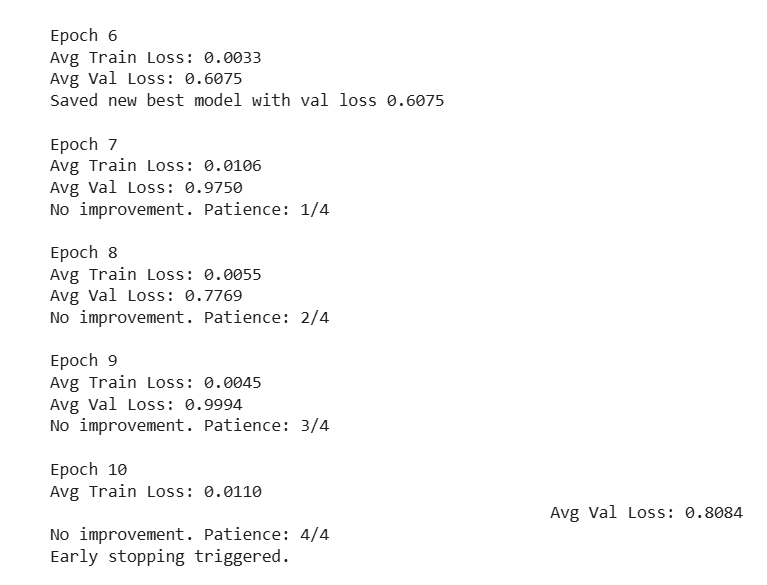

best score = 0.6

### exp2

+ dropout from 0.2 to 0.3
+ weight_decay=3e-4


In [ ]:
# #try2

train_loop(model, train_loader, val_loader, criterion, optimizer, epochs=10, save_path="best_model_3.pth", patience=3)


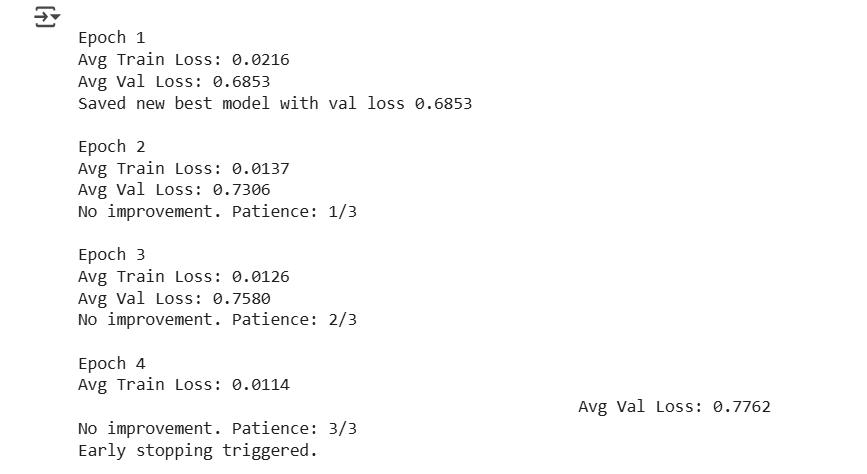

best score is actually the first one...0.68

### exp3

+ added  scheduler

In [ ]:
#try3

train_loop(model, train_loader, val_loader, criterion, optimizer, epochs=10, save_path="best_model_4.pth", patience=3)


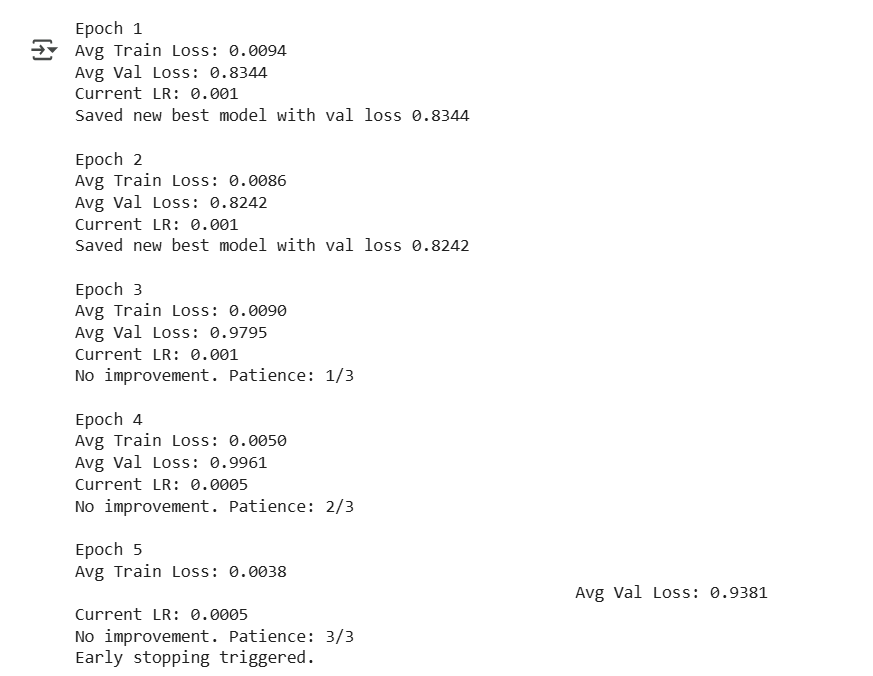

best score is 0.82...seems like i've done smth real wrong

## Inference with best model from exp1

let's get the best model from exp1 with 0.6 loss

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [ ]:
model.load_state_dict(torch.load("/kaggle/working/best_model_2.pth", map_location=device))
model.eval()



### LM defeated

--- here was my try to use LM but somehow it didn't work out as well as I expected and I also cleared some cells :(

In [ ]:
# unique_texts[:5]

['восемнадцать тысяч восемьсот восемьдесят два',
 'восемнадцать тысяч восемьсот пятьдесят девять',
 'восемнадцать тысяч восемьсот сорок один',
 'восемнадцать тысяч двести двадцать девять',
 'восемнадцать тысяч семьсот восемьдесят шесть']

In [ ]:
# lm_text_path = "/kaggle/working/lm_text_3.txt"

In [ ]:
# def text_to_letter_string(text):
#     return " ".join(text.strip().replace("ё", "е"))

# letter_lines = [text_to_letter_string(t) for t in unique_texts]

# with open(lm_text_path, "w", encoding="utf-8") as f:
#     for line in letter_lines:
#         f.write(line + "\n")



In [ ]:
# # Посмотрим первые строки
# with open(lm_text_path, "r", encoding="utf-8") as f:
#     preview = [next(f).strip() for _ in range(10)]

# for line in preview:
#     print(repr(line))


'в о с е м н а д ц а т ь   т ы с я ч   в о с е м ь с о т   в о с е м ь д е с я т   д в а'
'в о с е м н а д ц а т ь   т ы с я ч   в о с е м ь с о т   п я т ь д е с я т   д е в я т ь'
'в о с е м н а д ц а т ь   т ы с я ч   в о с е м ь с о т   с о р о к   о д и н'
'в о с е м н а д ц а т ь   т ы с я ч   д в е с т и   д в а д ц а т ь   д е в я т ь'
'в о с е м н а д ц а т ь   т ы с я ч   с е м ь с о т   в о с е м ь д е с я т   ш е с т ь'
'в о с е м н а д ц а т ь   т ы с я ч   с е м ь с о т   п я т ь'
'в о с е м н а д ц а т ь   т ы с я ч   с о р о к   ш е с т ь'
'в о с е м н а д ц а т ь   т ы с я ч   с т о   д в а д ц а т ь   в о с е м ь'
'в о с е м н а д ц а т ь   т ы с я ч   ш е с т ь с о т   т р и'
'в о с е м н а д ц а т ь   т ы с я ч   ш е с т ь с о т   ш е с т ь д е с я т   ч е т ы р е'


In [ ]:
# # Убедимся, что все символы в letter_lines входят в vocab
# vocab_set = set(vocab)
# bad_lines = []

# for line in letter_lines:
#     for char in line.replace(" ", ""):
#         if char not in vocab_set:
#             bad_lines.append((line, char))
#             break

# print(f"Проблемных строк: {len(bad_lines)}")
# if bad_lines:
#     print("Примеры ошибок:", bad_lines[:3])


Проблемных строк: 0


все ок, создаем арпу

In [ ]:
# !kenlm/build/bin/lmplz -o 3 --discount_fallback < /kaggle/working/lm_text_3.txt > /kaggle/working/lm_3.arpa


In [ ]:
# !kenlm/build/bin/build_binary /kaggle/working/lm_3.arpa /kaggle/working/lm_3.binary


Reading /kaggle/working/lm_3.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


In [ ]:
# from pyctcdecode import build_ctcdecoder

# decoder = build_ctcdecoder(
#     labels=vocab,
#     kenlm_model_path="/kaggle/working/lm_3.binary",
#     alpha=0.8,
#     beta=1.0
# )


In [ ]:
!pip install jiwer


In [ ]:
model.to(device)


In [ ]:
model.eval()

Удалила важные ячейки, кажется. Там были проблемы с ЛМ - как будто слишком мало материала, и модель не научилась ничему, ну и CER выдавала странный. Поэтому пошла в более легкий декод

In [ ]:
vocab = [c for i, c in sorted(idx2char.items()) if i != 0]


In [ ]:
print(vocab)


[' ', 'а', 'в', 'д', 'е', 'и', 'к', 'м', 'н', 'о', 'п', 'р', 'с', 'т', 'ц', 'ч', 'ш', 'ы', 'ь', 'я']


###Greedy?

In [ ]:
argmax_preds = log_probs.squeeze(0).argmax(dim=-1).cpu().numpy()
print("Raw argmax:", argmax_preds)


Raw argmax: [ 3  3 10 13  5  5  8 19 13 13 10 14  1  1 10 10 12 10  7  7  1  4  4  5
  3 20 14  1  1  4 14 18 13 20  4 16  1  1  4  4  5  3 20 14 19 13 10 14
  1  1 11 11 20 14 14 19 19 19 19 19  0]


In [ ]:
def ctc_decode(pred_ids):
    prev = -1
    result = []
    for p in pred_ids:
        if p != prev and p != 0:
            result.append(idx2char[p])
        prev = p
    return ''.join(result)

print("CTC Decoded:", ctc_decode(argmax_preds))


CTC Decoded: восемьсот орок девят дтысядч девятьсот пять


In [ ]:
batch = next(iter(val_loader))
print(batch.keys())

#проверяла, есть ли нужное поле в батче с валидации

dict_keys(['logmel', 'logmel_len', 'tokens', 'token_len', 'text'])


let's hardcode...

In [ ]:
import Levenshtein as lev

known_words = set([
    "ноль", "один", "два", "три", "четыре", "пять", "шесть", "семь", "восемь", "девять",
    "десять", "одиннадцать", "двенадцать", "тринадцать", "четырнадцать", "пятнадцать", "шестнадцать",
    "семнадцать", "восемнадцать", "девятнадцать",
    "двадцать", "тридцать", "сорок", "пятьдесят", "шестьдесят", "семьдесят", "восемьдесят", "девяносто",
    "сто", "двести", "триста", "четыреста", "пятьсот", "шестьсот", "семьсот", "восемьсот", "девятьсот",
    "тысяча", "тысячи", "тысяч"
])

def correct_word(word):
    candidates = [(w, lev.distance(word, w)) for w in known_words]
    best_match = min(candidates, key=lambda x: x[1])
    return best_match[0] if best_match[1] <= 2 else word

def fuzzy_text_to_number(text):
    words = text.lower().split()
    corrected = [correct_word(w) for w in words]
    clean_text = " ".join(corrected)
    try:
        return text_to_number(clean_text)
    except:
        return -1


In [ ]:
def text_to_number(text: str) -> int:
    units = {
        "ноль": 0, "один": 1, "два": 2, "три": 3, "четыре": 4, "пять": 5,
        "шесть": 6, "семь": 7, "восемь": 8, "девять": 9,
        "десять": 10, "одиннадцать": 11, "двенадцать": 12, "тринадцать": 13,
        "четырнадцать": 14, "пятнадцать": 15, "шестнадцать": 16,
        "семнадцать": 17, "восемнадцать": 18, "девятнадцать": 19
    }

    tens = {
        "двадцать": 20, "тридцать": 30, "сорок": 40, "пятьдесят": 50,
        "шестьдесят": 60, "семьдесят": 70, "восемьдесят": 80, "девяносто": 90
    }

    hundreds = {
        "сто": 100, "двести": 200, "триста": 300, "четыреста": 400,
        "пятьсот": 500, "шестьсот": 600, "семьсот": 700,
        "восемьсот": 800, "девятьсот": 900
    }

    multiples = {
        "тысяча": 1000, "тысячи": 1000, "тысяч": 1000
    }

    words = text.strip().lower().split()
    result = 0
    current = 0

    for word in words:
        if word in units:
            current += units[word]
        elif word in tens:
            current += tens[word]
        elif word in hundreds:
            current += hundreds[word]
        elif word in multiples:
            result += current * multiples[word]
            current = 0
        else:

            pass

    return result + current


In [ ]:

references, predictions = [], []
for batch in tqdm(val_loader):
    logmel = batch["logmel"].to(device)
    with torch.no_grad():
        log_probs = model(logmel)
        argmax_preds = log_probs.argmax(dim=-1).cpu().numpy()
        for i in range(len(argmax_preds)):
            pred_text = ctc_decode(argmax_preds[i])
            pred_num = fuzzy_text_to_number(pred_text)
            true_num = text_to_number(batch["text"][i])
            predictions.append(str(pred_num))
            references.append(str(true_num))


100%|██████████| 71/71 [00:05<00:00, 12.99it/s]


In [ ]:
references[:3]

['849905', '967653', '427524']

In [ ]:
predictions[:3]

['849905', '216053', '30920']

In [ ]:
cer_score = cer(references, predictions)
print(f"\nCER (fuzzy number decoding): {cer_score:.4f}")


CER (fuzzy number decoding): 0.3712


early try but not with number transcriptions, with words

In [ ]:
from jiwer import cer

references, predictions = [], []
for batch in tqdm(val_loader):
    logmel = batch["logmel"].to(device)
    tokens = batch["tokens"]
    with torch.no_grad():
        log_probs = model(logmel)
        argmax_preds = log_probs.argmax(dim=-1).cpu().numpy()
        for i in range(len(argmax_preds)):
            pred = ctc_decode(argmax_preds[i])
            true = batch["text"][i]
            predictions.append(pred)
            references.append(true)

cer_score = cer(references, predictions)
print(f"\nCER (greedy): {cer_score:.4f}")


100%|██████████| 71/71 [00:05<00:00, 13.39it/s]



CER (greedy): 0.1918
